In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt,erfc,exp

from scipy.optimize import curve_fit


In [13]:
data_Q = pd.read_excel(r'C:\Users\Nicolas Onillon\Documents\UNINe\géologie\dispersion.xlsx','debit')
data_conductivite = pd.read_excel(r'C:\Users\Nicolas Onillon\Documents\UNINe\géologie\dispersion.xlsx','conductivite')
Q = data_Q['Q_[m3/s]']
Q_err = data_Q['err_Q']
t0 = [38,40,39]
t_err = [1,1,1]
t = data_conductivite['temps_[s]']
C = data_conductivite['C_[microS/cm]']
#erreur C
C_err = []
for k in C:
    if k < (2000-385):
        C_err.append(2)
    else: C_err.append(20)

In [14]:
def moyenne_ponderee(x,sigma):
    w = []
    for i in range(len(sigma)):
        w.append(1/sigma[i]**2)

    # Calcul des xiwi
    wx = []
    for i in range(len(x)):
        wx.append(x[i]*w[i])

    # Calcul de la moyenne ponderee
    mean = sum(wx)/sum(w)

    # Calcul de l'ecart à la moyenne de xi
    ecart_moy = []
    for i in range(len(x)):
        ecart_moy.append(w[i]*(x[i]-mean)**2)

    # Calcul sigma
    sigma_x = np.sqrt(sum(ecart_moy)/sum(w))

    return mean, 2*sigma_x

In [15]:
# Calcul de alpha moyen et de son erreur
mean_Q, sigma_Q = moyenne_ponderee(Q, Q_err)
print(f'Q = {mean_Q} +/- {sigma_Q} m3/s')

mean_t, sigma_t = moyenne_ponderee(t0, t_err)
print(f't = {mean_t} +/- {sigma_t} sec')

Q = 2.9921593052612783e-06 +/- 1.1094466429484863e-08 m3/s
t = 39.0 +/- 1.632993161855452 sec


porosité: 0.44471016844165806 +/- 0.0003411344914452836
dispersivité: 0.0009275754516433202 +/- 2.2009114303680343e-05


C:\Users\Nicolas Onillon\AppData\Local\Temp\ipykernel_12376\2398280990.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  er1 = (l-adv*ti)/(2*np.sqrt(D*ti))
C:\Users\Nicolas Onillon\AppData\Local\Temp\ipykernel_12376\2398280990.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  er2 = (l+adv*ti)/(2*np.sqrt(D*ti))
C:\Users\Nicolas Onillon\AppData\Local\Temp\ipykernel_12376\2398280990.py:15: RuntimeWarning: invalid value encountered in sqrt
  er1 = (l-adv*ti)/(2*np.sqrt(D*ti))
C:\Users\Nicolas Onillon\AppData\Local\Temp\ipykernel_12376\2398280990.py:16: RuntimeWarning: invalid value encountered in sqrt
  er2 = (l+adv*ti)/(2*np.sqrt(D*ti))


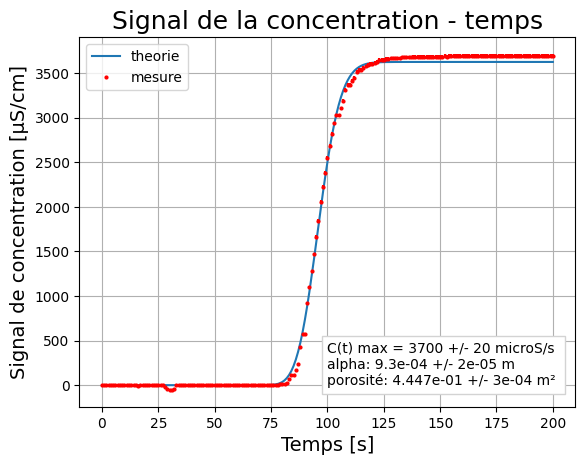

In [16]:
'''parametres fixes'''
A, A_err = 22*10**(-4), 3*10**(-4)  # m2
l, l_err = 0.295, 0.04    # m
C0, C0_err = 3625, 11   # microS/cm
q = mean_Q/A           # m/s
q_err = q*sqrt((sigma_Q/mean_Q)**2+(A_err/A)**2)
d0 = 1.3*10**(-9)*0.7 # m2/s

def function_for_fit(t, n, alpha):
    y = []
    adv = q/n
    D = alpha*adv+d0
    ex = adv*l/D
    for ti in t:
        er1 = (l-adv*ti)/(2*np.sqrt(D*ti))
        er2 = (l+adv*ti)/(2*np.sqrt(D*ti))
        y.append(C0/2*(erfc(er1)+np.exp(ex)*erfc(er2)))
    return y

'''valeurs'''
param_opt, param_cov = curve_fit(function_for_fit,t,C)
n_opt, alpha_opt = param_opt
n_cov, alpha_cov = param_cov
n_cov, alpha_cov = n_cov[0], alpha_cov[0]
n_err, alpha_err = np.sqrt(n_cov).squeeze(), np.sqrt(alpha_cov).squeeze()
C_opt = function_for_fit(t,n_opt,alpha_opt)
print(f"porosité: {n_opt} +/- {n_err}")
print(f"dispersivité: {alpha_opt} +/- {alpha_err}")

'''graphe'''
fig, cond = plt.subplots()
cond.plot(t,C_opt,label = 'theorie')
cond.plot(t,C,marker='o',color='r', linestyle='none',markersize=2,label = 'mesure')
cond.errorbar(t,C,yerr=C_err,color='r',linestyle='none')
cond.set_xlabel('Temps [s]',fontsize=14)
cond.set_ylabel('Signal de concentration [\u00B5S/cm]',fontsize=14)
cond.set_title('Signal de la concentration - temps',fontsize=18)
cond.grid()
cond.text (100,0, f"C(t) max = 3700 +/- 20 microS/s \nalpha: {alpha_opt:.1e} +/- {alpha_err:.0e} m \nporosité: {n_opt:.3e} +/- {n_err:.0e} m\u00B2",bbox=dict(facecolor='white',edgecolor='lightgrey'))
plt.legend()

#plt.savefig(f'C:/Users/Nicolas Onillon/Documents/UNINe/géologie/concentration.pdf')

In [17]:
'''vitesse advection'''
# selon porosité
n_t, n_t_err = 0.422, 0.006
n_ta, n_ta_err = 0.463, 0.005
adv_t = q/n_t # m/s
adv_ta = q/n_ta
adv_t_err = adv_t*sqrt((q_err/q)**2+(n_t_err/n_t)**2)
adv_ta_err = adv_ta*sqrt((q_err/q)**2+(n_ta_err/n_ta)**2)
print(f"vitesse moyenne d'advection théorique: {adv_t} +/- {adv_t_err} m/s")
print(f"vitesse moyenne d'advection non tassé théorique: {adv_ta} +/- {adv_ta_err} m/s")

#selon dispersion
ti = 96
ti_err = 1
adv_m = l/96
adv_m_err = adv_m*sqrt((l_err/l)**2+(ti_err/ti)**2)
print(f"vitesse moyenne d'advection manuelle: {adv_m} +/- {adv_m_err} m/s")

vitesse moyenne d'advection théorique: 0.0032229204063563962 +/- 0.0004420331534992561 m/s
vitesse moyenne d'advection non tassé théorique: 0.002937521407089415 +/- 0.0004019728463474887 m/s
vitesse moyenne d'advection manuelle: 0.0030729166666666665 +/- 0.000417894391339963 m/s


C:\Users\Nicolas Onillon\AppData\Local\Temp\ipykernel_12376\2398280990.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  er1 = (l-adv*ti)/(2*np.sqrt(D*ti))
C:\Users\Nicolas Onillon\AppData\Local\Temp\ipykernel_12376\2398280990.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  er2 = (l+adv*ti)/(2*np.sqrt(D*ti))


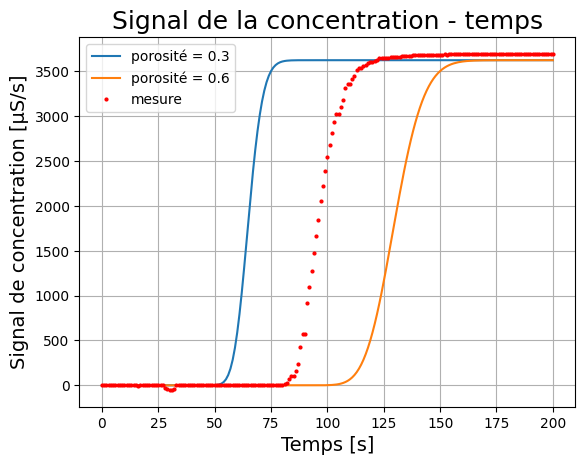

In [18]:
'''varier n'''
C1 = function_for_fit(t,0.3,alpha_opt)
C2 = function_for_fit(t,0.6,alpha_opt)

'''graphe'''
fig, cond = plt.subplots()
cond.plot(t,C1,label = 'porosité = 0.3')
cond.plot(t,C2,label = 'porosité = 0.6')
cond.plot(t,C,marker='o',color='r', linestyle='none',markersize=2,label = 'mesure')
cond.set_xlabel('Temps [s]',fontsize=14)
cond.set_ylabel('Signal de concentration [\u00B5S/s]',fontsize=14)
cond.set_title('Signal de la concentration - temps',fontsize=18)
cond.grid()
plt.legend()

#plt.savefig(f'C:/Users/Nicolas Onillon/Documents/UNINe/géologie/variation_n.pdf')

C:\Users\Nicolas Onillon\AppData\Local\Temp\ipykernel_12376\2398280990.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  er1 = (l-adv*ti)/(2*np.sqrt(D*ti))
C:\Users\Nicolas Onillon\AppData\Local\Temp\ipykernel_12376\2398280990.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  er2 = (l+adv*ti)/(2*np.sqrt(D*ti))


alpha1: 0.00045
alpha2: 0.027


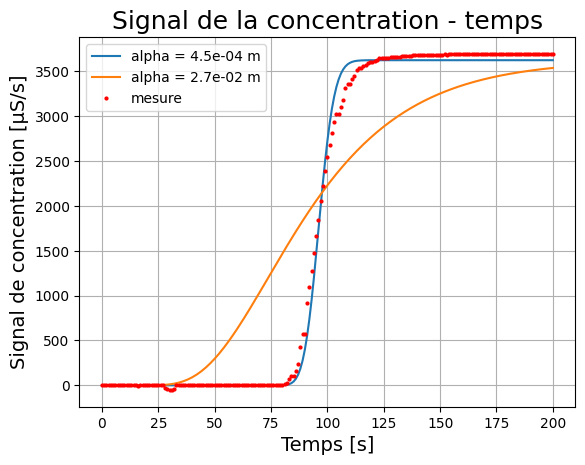

In [22]:
'''varier alpha'''
alpha1, alpha2 = 0.00045, 0.027
C1 = function_for_fit(t,n_opt,alpha1)
C2 = function_for_fit(t,n_opt,alpha2)

print(f"alpha1: {alpha1}\nalpha2: {alpha2}")
'''graphe'''
fig, cond = plt.subplots()
cond.plot(t,C1,label = f'alpha = {alpha1:.1e} m')
cond.plot(t,C2,label = f'alpha = {alpha2:.1e} m')
cond.plot(t,C,marker='o',color='r', linestyle='none',markersize=2,label = 'mesure')
cond.set_xlabel('Temps [s]',fontsize=14)
cond.set_ylabel('Signal de concentration [\u00B5S/s]',fontsize=14)
cond.set_title('Signal de la concentration - temps',fontsize=18)
cond.grid()
plt.legend()

#plt.savefig(f'C:/Users/Nicolas Onillon/Documents/UNINe/géologie/variation_alpha.pdf')